In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving crop_yield.csv to crop_yield.csv


In [ ]:
file = list(uploaded.keys())[0]
df = pd.read_csv(file)

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 19689
Columns: 10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [ ]:
print(df.isnull().sum())

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64


In [ ]:
df = df.dropna().copy()

print("Missing values removed!")
print("Dataset shape:", df.shape)

Missing values removed!
Dataset shape: (19689, 10)


In [ ]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


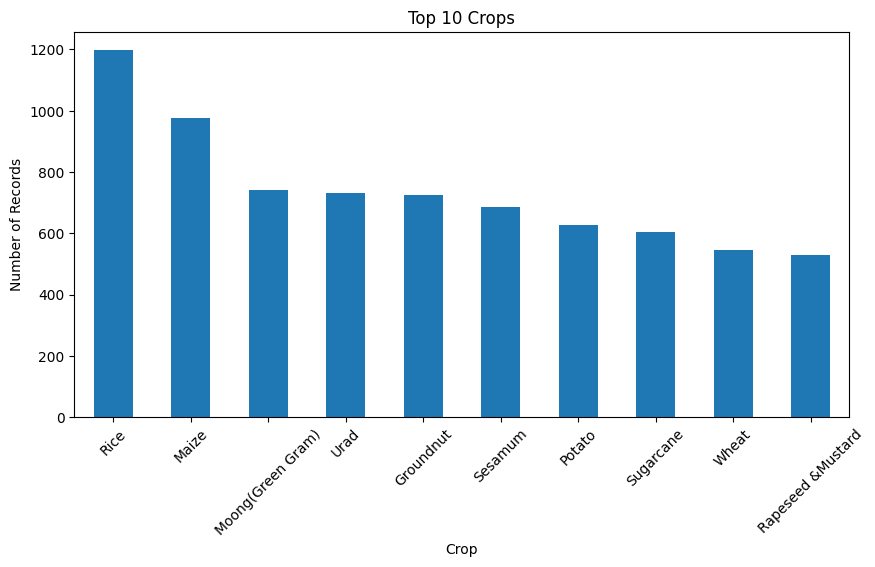

In [ ]:
plt.figure(figsize=(10,5))

df["Crop"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.show()

In [ ]:
features = [
    "Crop", "Crop_Year", "Season", "State",
    "Area", "Annual_Rainfall", "Fertilizer", "Pesticide"
]

X = df[features]
y = df["Yield"]

print("Input features:")
print(X.columns.tolist())
print("\nTarget: Yield")

Input features:
['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']

Target: Yield


In [ ]:
X = pd.get_dummies(
    X,
    columns=["Crop", "Season", "State"],
    drop_first=True
)

print("Categorical data encoded!")
print("Number of features:", X.shape[1])

Categorical data encoded!
Number of features: 93


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 15751
Testing samples: 3938


In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Regressor created!")

Random Forest Regressor created!


In [ ]:
rf.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
rf_pred = rf.predict(X_test)

print("Predictions generated!")
print("First 5 predictions:")
print(rf_pred[:5])

Predictions generated!
First 5 predictions:
[4.01409508 1.43124956 6.60724136 0.93545914 0.64703185]


In [ ]:
mae = mean_absolute_error(y_test, rf_pred)
rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Random Forest Performance
MAE : 9.557
RMSE: 126.187
R²  : 0.98


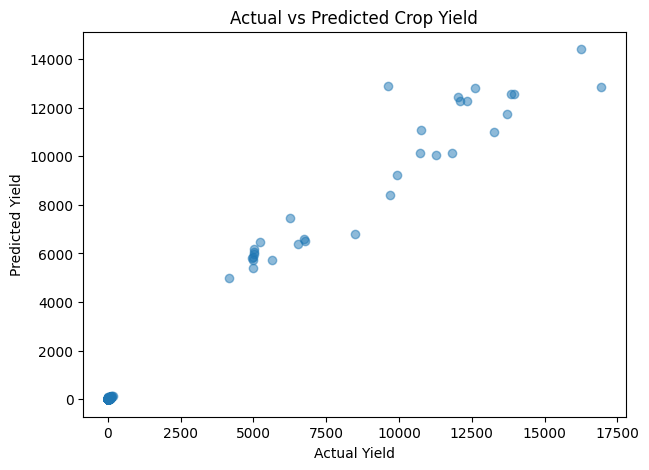

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_pred, alpha=0.5)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Crop Yield")

plt.show()

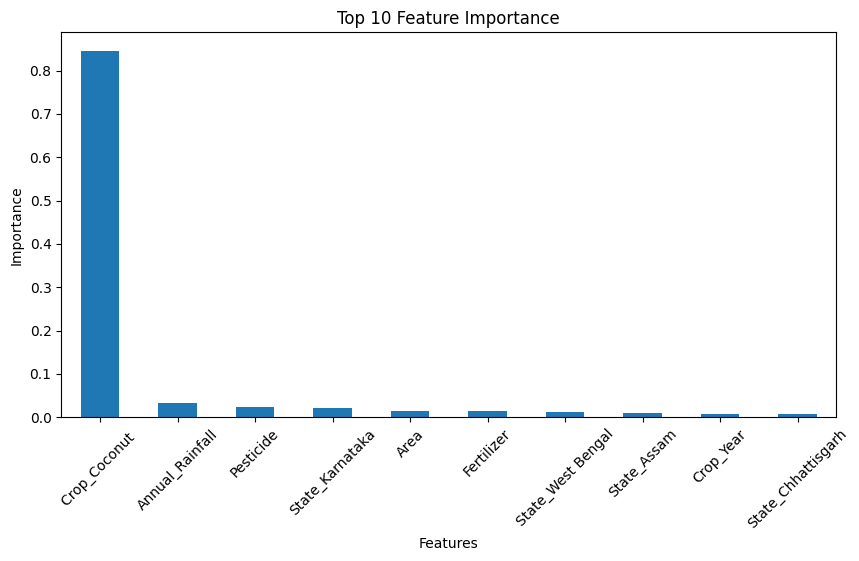

In [ ]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(10)

importance.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("🌾 CROP YIELD PREDICTION SYSTEM")
print("=" * 40)

crop = input("Enter Crop: ")
state = input("Enter State: ")
season = input("Enter Season: ")
year = int(input("Enter Crop Year: "))
area = float(input("Enter Area: "))
rainfall = float(input("Enter Annual Rainfall: "))
fertilizer = float(input("Enter Fertilizer: "))
pesticide = float(input("Enter Pesticide: "))

new_data = pd.DataFrame([{
    "Crop": crop,
    "Crop_Year": year,
    "Season": season,
    "State": state,
    "Area": area,
    "Annual_Rainfall": rainfall,
    "Fertilizer": fertilizer,
    "Pesticide": pesticide
}])

new_data = pd.get_dummies(
    new_data,
    columns=["Crop", "Season", "State"],
    drop_first=True
)

new_data = new_data.reindex(
    columns=X.columns,
    fill_value=0
)

prediction = rf.predict(new_data)[0]

print("\n🌱 PREDICTION RESULT")
print("=" * 40)
print("Crop:", crop)
print("State:", state)
print("Season:", season)
print("Predicted Yield:", round(prediction, 3))

🌾 CROP YIELD PREDICTION SYSTEM
Enter Crop: Rice
Enter State: Tamil Nadu
Enter Season: Kharif
Enter Crop Year: 2020
Enter Area: 1000
Enter Annual Rainfall: 1200
Enter Fertilizer: 150000
Enter Pesticide: 500

🌱 PREDICTION RESULT
Crop: Rice
State: Tamil Nadu
Season: Kharif
Predicted Yield: 1.181
